In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
global_df = pd.read_csv(
    '/content/drive/MyDrive/[엔터] Netflix Top 10 Weekly Dataset/all-weeks-global.csv',
    encoding='latin1'
)

country_df = pd.read_csv(
    '/content/drive/MyDrive/[엔터] Netflix Top 10 Weekly Dataset/all-weeks-countries.csv',
    encoding='latin1'
)

In [4]:
print(global_df.shape)
print(country_df.shape)

(1160, 7)
(54520, 8)


In [5]:
display(global_df.head())
display(country_df.head())

,ï»¿week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,cumulative_weeks_in_top_10
0,2022-01-16,Films (English),1,Brazen,NaN,45340000,1
1,2022-01-16,Films (English),2,Don't Look Up,NaN,28390000,4
2,2022-01-16,Films (English),3,Mother/Android,NaN,23170000,2
3,2022-01-16,Films (English),4,The Secret Life of Pets 2,NaN,9390000,1
4,2022-01-16,Films (English),5,Just Go With It,NaN,8790000,3


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2022-01-16,Films,1,Brazen,NaN,1
1,Argentina,AR,2022-01-16,Films,2,Mother/Android,NaN,2
2,Argentina,AR,2022-01-16,Films,3,The Clovehitch Killer,NaN,1
3,Argentina,AR,2022-01-16,Films,4,The Secret Life of Pets 2,NaN,1
4,Argentina,AR,2022-01-16,Films,5,Don't Look Up,NaN,4


In [6]:
print(global_df.columns.tolist())
print(country_df.columns.tolist())

['ï»¿week', 'category', 'weekly_rank', 'show_title', 'season_title', 'weekly_hours_viewed', 'cumulative_weeks_in_top_10']
['country_name', 'country_iso2', 'week', 'category', 'weekly_rank', 'show_title', 'season_title', 'cumulative_weeks_in_top_10']


In [7]:
global_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1160 entries, 0 to 1159
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ï»¿week                     1160 non-null   object
 1   category                    1160 non-null   object
 2   weekly_rank                 1160 non-null   int64 
 3   show_title                  1160 non-null   object
 4   season_title                570 non-null    object
 5   weekly_hours_viewed         1160 non-null   int64 
 6   cumulative_weeks_in_top_10  1160 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 63.6+ KB


In [8]:
country_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54520 entries, 0 to 54519
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   country_name                54520 non-null  object
 1   country_iso2                54520 non-null  object
 2   week                        54520 non-null  object
 3   category                    54520 non-null  object
 4   weekly_rank                 54520 non-null  int64 
 5   show_title                  54520 non-null  object
 6   season_title                26984 non-null  object
 7   cumulative_weeks_in_top_10  54520 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 3.3+ MB


In [9]:
global_df = global_df.rename(columns={'ï»¿week': 'week'})

In [10]:
print(global_df.columns)

Index(['week', 'category', 'weekly_rank', 'show_title', 'season_title',
       'weekly_hours_viewed', 'cumulative_weeks_in_top_10'],
      dtype='object')


In [11]:
global_df['week'] = pd.to_datetime(global_df['week'])
country_df['week'] = pd.to_datetime(country_df['week'])

In [12]:
print(global_df['week'].dtype)
print(country_df['week'].dtype)

datetime64[ns]
datetime64[ns]


In [13]:
print('GLOBAL 결측치')
display(global_df.isnull().sum())

print('\nCOUNTRY 결측치')
display(country_df.isnull().sum())

GLOBAL 결측치


,0
week,0
category,0
weekly_rank,0
show_title,0
season_title,590
weekly_hours_viewed,0
cumulative_weeks_in_top_10,0



COUNTRY 결측치


,0
country_name,0
country_iso2,0
week,0
category,0
weekly_rank,0
show_title,0
season_title,27536
cumulative_weeks_in_top_10,0


In [14]:
print('GLOBAL 중복 행:', global_df.duplicated().sum())
print('COUNTRY 중복 행:', country_df.duplicated().sum())

GLOBAL 중복 행: 0
COUNTRY 중복 행: 0


In [15]:
print('GLOBAL 기간')
print(global_df['week'].min(), '~', global_df['week'].max())

print('\nCOUNTRY 기간')
print(country_df['week'].min(), '~', country_df['week'].max())

GLOBAL 기간
2021-07-04 00:00:00 ~ 2022-01-16 00:00:00

COUNTRY 기간
2021-07-04 00:00:00 ~ 2022-01-16 00:00:00


In [16]:
print('GLOBAL category')
display(global_df['category'].value_counts())

print('\nCOUNTRY category')
display(country_df['category'].value_counts())

GLOBAL category


,count
category,
Films (English),290
Films (Non-English),290
TV (English),290
TV (Non-English),290



COUNTRY category


,count
category,
Films,27260
TV,27260


In [17]:
display(
    global_df[
        ['weekly_rank',
         'weekly_hours_viewed',
         'cumulative_weeks_in_top_10']
    ].describe()
)

,weekly_rank,weekly_hours_viewed,cumulative_weeks_in_top_10
count,1160.00000,1.160000e+03,1160.000000
mean,5.50000,1.983321e+07,2.770690
std,2.87352,3.372892e+07,2.450723
min,1.00000,9.300000e+05,1.000000
25%,3.00000,7.207500e+06,1.000000
50%,5.50000,1.207500e+07,2.000000
75%,8.00000,2.031750e+07,3.000000
max,10.00000,5.717600e+08,18.000000


In [18]:
display(
    country_df[
        ['weekly_rank',
         'cumulative_weeks_in_top_10']
    ].describe()
)

,weekly_rank,cumulative_weeks_in_top_10
count,54520.000000,54520.000000
mean,5.500000,2.935675
std,2.872308,3.375848
min,1.000000,1.000000
25%,3.000000,1.000000
50%,5.500000,2.000000
75%,8.000000,3.000000
max,10.000000,29.000000


In [19]:
print('GLOBAL season_title 결측치 - category별')
display(
    global_df.groupby('category')['season_title']
    .apply(lambda x: x.isnull().sum())
)

print('\nCOUNTRY season_title 결측치 - category별')
display(
    country_df.groupby('category')['season_title']
    .apply(lambda x: x.isnull().sum())
)

GLOBAL season_title 결측치 - category별


,season_title
category,
Films (English),290
Films (Non-English),288
TV (English),1
TV (Non-English),11



COUNTRY season_title 결측치 - category별


,season_title
category,
Films,27233
TV,303


In [20]:
global_tv_missing = global_df[
    global_df['category'].str.contains('TV') &
    global_df['season_title'].isnull()
]

display(
    global_tv_missing[
        ['week', 'category', 'show_title', 'season_title',
         'weekly_rank', 'cumulative_weeks_in_top_10']
    ]
)

,week,category,show_title,season_title,weekly_rank,cumulative_weeks_in_top_10
587,2021-10-10,TV (English),Dave Chappelle: The Closer,NaN,8,1
719,2021-09-19,TV (Non-English),Carrossel,NaN,10,10
797,2021-09-05,TV (Non-English),Carrossel,NaN,8,9
834,2021-08-29,TV (Non-English),Carrossel,NaN,5,8
876,2021-08-22,TV (Non-English),Carrossel,NaN,7,7
916,2021-08-15,TV (Non-English),Carrossel,NaN,7,6
954,2021-08-08,TV (Non-English),Carrossel,NaN,5,5
996,2021-08-01,TV (Non-English),Carrossel,NaN,7,4
998,2021-08-01,TV (Non-English),Chiquititas,NaN,9,1
1033,2021-07-25,TV (Non-English),Carrossel,NaN,4,3


In [21]:
country_tv_missing = country_df[
    (country_df['category'] == 'TV') &
    country_df['season_title'].isnull()
]

display(
    country_tv_missing[
        ['country_name', 'week', 'show_title',
         'season_title', 'weekly_rank',
         'cumulative_weeks_in_top_10']
    ].head(50)
)

,country_name,week,show_title,season_title,weekly_rank,cumulative_weeks_in_top_10
2038,Bahamas,2021-10-10,Dave Chappelle: The Closer,NaN,9,1
2796,Bahrain,2021-08-08,Encounter,NaN,7,1
3056,Bangladesh,2021-11-28,Jonas Brothers Family Roast,NaN,7,1
3377,Bangladesh,2021-08-08,Encounter,NaN,8,1
4657,Brazil,2022-01-16,Chiquititas,NaN,8,25
4679,Brazil,2022-01-09,Chiquititas,NaN,10,24
4715,Brazil,2021-12-26,Chiquititas,NaN,6,23
4717,Brazil,2021-12-26,Carrossel,NaN,8,25
4735,Brazil,2021-12-19,Chiquititas,NaN,6,22
4736,Brazil,2021-12-19,Carrossel,NaN,7,24


In [22]:
display(
    global_df[
        global_df['category'].str.contains('Films') &
        global_df['season_title'].notnull()
    ][
        ['week', 'category', 'show_title', 'season_title']
    ]
)

,week,category,show_title,season_title
898,2021-08-15,Films (Non-English),Navarasa,Navarasa: Volume 1
937,2021-08-08,Films (Non-English),Navarasa,Navarasa: Volume 1


In [23]:
tv_df = global_df[
    global_df['category'].str.contains('TV')
]

season_count = (
    tv_df.groupby('show_title')['season_title']
    .nunique()
    .sort_values(ascending=False)
)

display(season_count.head(20))

,season_title
show_title,
Money Heist,5
Cobra Kai,4
Elite,4
Lucifer,4
Lost in Space,3
Manifest,3
Sex Education,3
CoComelon,3
You,3


In [24]:
multi_season_titles = season_count[
    season_count > 1
]

print('여러 season_title을 가진 TV 작품 수:',
      len(multi_season_titles))

display(multi_season_titles)

여러 season_title을 가진 TV 작품 수: 22


,season_title
show_title,
Money Heist,5
Cobra Kai,4
Elite,4
Lucifer,4
Lost in Space,3
Manifest,3
Sex Education,3
CoComelon,3
You,3


In [25]:
multi_season_names = multi_season_titles.index

display(
    tv_df[
        tv_df['show_title'].isin(multi_season_names)
    ][
        ['show_title', 'season_title']
    ]
    .drop_duplicates()
    .sort_values(['show_title', 'season_title'])
)

,show_title,season_title
789,CoComelon,CoComelon: Season 1
629,CoComelon,CoComelon: Season 3
148,CoComelon,CoComelon: Season 4
66,Cobra Kai,Cobra Kai: Season 1
69,Cobra Kai,Cobra Kai: Season 2
29,Cobra Kai,Cobra Kai: Season 3
21,Cobra Kai,Cobra Kai: Season 4
956,Control Z,Control Z: Season 1
879,Control Z,Control Z: Season 2
1155,Elite,Elite: Season 1


In [26]:
global_df['content_key'] = global_df.apply(
    lambda row: row['season_title']
    if pd.notnull(row['season_title'])
    else row['show_title'],
    axis=1
)
#시즌명이 있으면 → season_title 사용
#시즌명이 없으면 → show_title 사용

In [27]:
display(
    global_df[
        ['show_title', 'season_title', 'content_key']
    ].drop_duplicates().head(30)
)

,show_title,season_title,content_key
0,Brazen,NaN,Brazen
1,Don't Look Up,NaN,Don't Look Up
2,Mother/Android,NaN,Mother/Android
3,The Secret Life of Pets 2,NaN,The Secret Life of Pets 2
4,Just Go With It,NaN,Just Go With It
5,Red Notice,NaN,Red Notice
6,Back to the Outback,NaN,Back to the Outback
7,Tides,NaN,Tides
8,Riverdance: The Animated Adventure,NaN,Riverdance: The Animated Adventure
9,The Clovehitch Killer,NaN,The Clovehitch Killer


In [28]:
content_weeks = (
    global_df
    .groupby(
        ['content_key', 'show_title', 'category'],
        as_index=False
    )
    ['cumulative_weeks_in_top_10']
    .max()
    .rename(
        columns={
            'cumulative_weeks_in_top_10': 'top10_weeks'
        }
    )
)

display(content_weeks.head())

,content_key,show_title,category,top10_weeks
0,1000 Miles from Christmas,1000 Miles from Christmas,Films (Non-English),2
1,14 Peaks: Nothing Is Impossible,14 Peaks: Nothing Is Impossible,Films (English),1
2,21 Jump Street,21 Jump Street,Films (English),1
3,211,211,Films (English),1
4,6 Underground,6 Underground,Films (English),1


In [29]:
content_weeks['top10_weeks'].describe()

,top10_weeks
count,439.000000
mean,2.642369
std,2.242620
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,18.000000


In [30]:
content_weeks['top10_weeks'].value_counts().sort_index()

,count
top10_weeks,
1,166
2,104
3,71
4,36
5,26
6,14
7,7
8,4
9,2


In [31]:
last_week = global_df['week'].max()

right_censored = (
    global_df[
        global_df['week'] == last_week
    ][
        ['content_key', 'show_title', 'category',
         'cumulative_weeks_in_top_10']
    ]
    .sort_values(
        'cumulative_weeks_in_top_10',
        ascending=False
    )
)

display(right_censored)
print('마지막 주 Top10 콘텐츠 수:', len(right_censored))
# 1. 마지막 주까지 Top10에 남아 있던 콘텐츠

,content_key,show_title,category,cumulative_weeks_in_top_10
39,Squid Game: Season 1,Squid Game,TV (Non-English),18
36,Money Heist: Part 5,Money Heist,TV (Non-English),13
38,Carinha de Anjo: Season 1,Carinha de Anjo,TV (Non-English),13
5,Red Notice,Red Notice,Films (English),10
31,The Queen of Flow: Season 2,The Queen of Flow,TV (Non-English),9
25,Manifest: Season 1,Manifest,TV (English),8
15,Major Grom: Plague Doctor,Major Grom: Plague Doctor,Films (Non-English),6
6,Back to the Outback,Back to the Outback,Films (English),6
27,The Witcher: Season 1,The Witcher,TV (English),6
22,The Witcher: Season 2,The Witcher,TV (English),5


마지막 주 Top10 콘텐츠 수: 40


In [32]:
display(
    content_weeks
    .groupby('category')['top10_weeks']
    .describe()
)
# 2. 카테고리별 유지기간 분포

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Films (English),144.0,2.013889,1.419081,1.0,1.0,2.0,3.00,10.0
Films (Non-English),116.0,2.500000,1.506508,1.0,1.0,2.0,3.00,9.0
TV (English),101.0,2.871287,2.091236,1.0,1.0,2.0,4.00,13.0
TV (Non-English),78.0,3.717949,3.713427,1.0,1.0,2.0,4.75,18.0


In [33]:
display(
    content_weeks['category']
    .value_counts()
)
#시작일 이전부터 흥행하던 작품 → 정확한 시작을 관측하지 못함
#종료일 이후까지 흥행하는 작품 → 정확한 종료를 관측하지 못함

,count
category,
Films (English),144
Films (Non-English),116
TV (English),101
TV (Non-English),78


In [34]:
# 깨진 문자열이 의심되는 제목 확인
suspect_titles = global_df[
    global_df['show_title'].str.contains(
        'Ã|â|Â',
        regex=True,
        na=False
    )
][['show_title', 'season_title']].drop_duplicates()

display(suspect_titles)
print('의심 제목 수:', len(suspect_titles))

,show_title,season_title
30,CafÃ© con aroma de mujer,CafÃ© con aroma de mujer: Season 1
33,Singleâs Inferno,Singleâs Inferno: Season 1
95,IntervenÃ§Ã£o,NaN
525,PokÃ©mon the Movie: Secrets of the Jungle,NaN
619,Freaks â You're One of Us,NaN
1018,TÃ´ Ryca,NaN
1104,PokÃ©mon Journeys: The Series,PokÃ©mon Journeys: The Series: Season 1


의심 제목 수: 7


In [35]:
suspect_seasons = global_df[
    global_df['season_title'].fillna('').str.contains(
        'Ã|â|Â',
        regex=True
    )
][['show_title', 'season_title']].drop_duplicates()

display(suspect_seasons)

,show_title,season_title
30,CafÃ© con aroma de mujer,CafÃ© con aroma de mujer: Season 1
33,Singleâs Inferno,Singleâs Inferno: Season 1
1104,PokÃ©mon Journeys: The Series,PokÃ©mon Journeys: The Series: Season 1


In [36]:
encoding_fix = {
    'CafÃ© con aroma de mujer': 'Café con aroma de mujer',
    'Singleâs Inferno': "Single’s Inferno",
    'IntervenÃ§Ã£o': 'Intervenção',
    'PokÃ©mon the Movie: Secrets of the Jungle': 'Pokémon the Movie: Secrets of the Jungle',
    "Freaks â You're One of Us": "Freaks – You're One of Us",
    'TÃ´ Ryca': 'Tô Ryca',
    'PokÃ©mon Journeys: The Series': 'Pokémon Journeys: The Series'
}

global_df['show_title'] = global_df['show_title'].replace(encoding_fix)
country_df['show_title'] = country_df['show_title'].replace(encoding_fix)

In [37]:
season_encoding_fix = {
    'CafÃ© con aroma de mujer: Season 1': 'Café con aroma de mujer: Season 1',
    'Singleâs Inferno: Season 1': "Single’s Inferno: Season 1",
    'PokÃ©mon Journeys: The Series: Season 1': 'Pokémon Journeys: The Series: Season 1'
}

global_df['season_title'] = global_df['season_title'].replace(season_encoding_fix)
country_df['season_title'] = country_df['season_title'].replace(season_encoding_fix)

In [38]:
global_df['content_key'] = global_df.apply(
    lambda row: row['season_title']
    if pd.notnull(row['season_title'])
    else row['show_title'],
    axis=1
)

In [39]:
#content_key 안에는 아직 깨진 문자열이 남아 있을 수 있기에 확
display(
    global_df[
        global_df['show_title'].str.contains(
            'Ã|â|Â',
            regex=True,
            na=False
        )
    ][['show_title', 'season_title']].drop_duplicates()
)

,show_title,season_title


In [40]:
display(
    global_df[
        global_df['season_title'].fillna('').str.contains(
            'Ã|â|Â',
            regex=True
        )
    ][['show_title', 'season_title']].drop_duplicates()
)

,show_title,season_title


In [41]:
# 콘텐츠별 최초/마지막 관측 시점과 누적 Top10 주수 정리
content_observation = (
    global_df
    .sort_values('week')
    .groupby(
        ['content_key', 'show_title', 'category'],
        as_index=False
    )
    .agg(
        first_week=('week', 'min'),
        last_week=('week', 'max'),
        first_cumulative=('cumulative_weeks_in_top_10', 'first'),
        max_cumulative=('cumulative_weeks_in_top_10', 'max')
    )
)

display(content_observation.head())

,content_key,show_title,category,first_week,last_week,first_cumulative,max_cumulative
0,1000 Miles from Christmas,1000 Miles from Christmas,Films (Non-English),2021-12-26,2022-01-02,1,2
1,14 Peaks: Nothing Is Impossible,14 Peaks: Nothing Is Impossible,Films (English),2021-12-05,2021-12-05,1,1
2,21 Jump Street,21 Jump Street,Films (English),2021-11-07,2021-11-07,1,1
3,211,211,Films (English),2021-11-14,2021-11-14,1,1
4,6 Underground,6 Underground,Films (English),2021-11-21,2021-11-21,1,1


In [42]:
# 데이터 시작 전부터 이미 흥행 중이었거나, 종료 시점에도 흥행 중인 콘텐츠 확인
dataset_start = global_df['week'].min()
dataset_end = global_df['week'].max()

left_censored = content_observation[
    (content_observation['first_week'] == dataset_start) &
    (content_observation['first_cumulative'] > 1)
]

right_censored = content_observation[
    content_observation['last_week'] == dataset_end
]

print('왼쪽 절단 콘텐츠:', len(left_censored))
print('오른쪽 절단 콘텐츠:', len(right_censored))
#데이터 최초 제공 주차의 모든 콘텐츠가 누적 1주로 기록되어 있어 데이터 제공 이전의 Top10 이력은 확인할 수 없었다.

왼쪽 절단 콘텐츠: 0
오른쪽 절단 콘텐츠: 40


In [43]:
# 양쪽 절단에 해당하지 않는 완전 관측 콘텐츠만 추출
complete_contents = content_observation[
    ~content_observation['content_key'].isin(left_censored['content_key']) &
    ~content_observation['content_key'].isin(right_censored['content_key'])
]

print('전체 콘텐츠:', len(content_observation))
print('완전 관측 콘텐츠:', len(complete_contents))

전체 콘텐츠: 439
완전 관측 콘텐츠: 399


In [44]:
# 데이터 종료 시점에도 Top10에 남아 있었는지 표시
content_observation['right_censored'] = (
    content_observation['last_week'] == dataset_end
)

display(
    content_observation[
        ['content_key', 'show_title', 'category',
         'max_cumulative', 'right_censored']
    ].head()
)

,content_key,show_title,category,max_cumulative,right_censored
0,1000 Miles from Christmas,1000 Miles from Christmas,Films (Non-English),2,False
1,14 Peaks: Nothing Is Impossible,14 Peaks: Nothing Is Impossible,Films (English),1,False
2,21 Jump Street,21 Jump Street,Films (English),1,False
3,211,211,Films (English),1,False
4,6 Underground,6 Underground,Films (English),1,False


In [45]:
# 오른쪽 절단 여부별 콘텐츠 수 확인
#데이터 확인 → 전처리 → 분석단위 설정
display(
    content_observation['right_censored']
    .value_counts()
)

,count
right_censored,
False,399
True,40


In [46]:
#EDA 1. Netflix에서 ‘장기 흥행’은 몇 주부터라고 볼 수 있을까
# 완전 관측된 TV 콘텐츠만 추출(실EDA)
tv_complete = content_observation[
    (~content_observation['right_censored']) &
    (content_observation['category'].str.contains('TV'))
].copy()

print('완전 관측 TV 콘텐츠 수:', len(tv_complete))

display(
    tv_complete['max_cumulative'].describe()
)

완전 관측 TV 콘텐츠 수: 159


,max_cumulative
count,159.000000
mean,3.000000
std,2.543296
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,16.000000


In [47]:
# TV 콘텐츠의 Top10 유지 주수별 개수 확인
display(
    tv_complete['max_cumulative']
    .value_counts()
    .sort_index()
)

,count
max_cumulative,
1,57
2,30
3,28
4,9
5,13
6,9
7,5
8,3
10,2


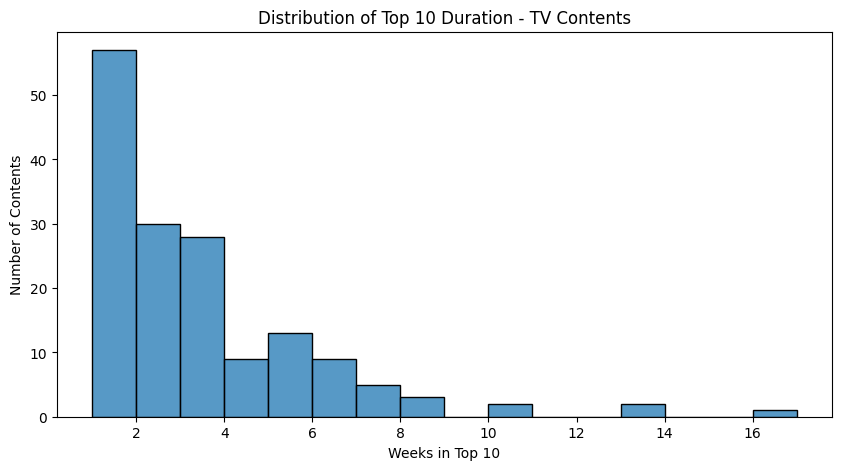

In [48]:
# 완전 관측 TV 콘텐츠의 Top10 유지기간 분포 시각화
plt.figure(figsize=(10, 5))

sns.histplot(
    data=tv_complete,
    x='max_cumulative',
    bins=range(
        1,
        int(tv_complete['max_cumulative'].max()) + 2
    )
)

plt.title('Distribution of Top 10 Duration - TV Contents')
plt.xlabel('Weeks in Top 10')
plt.ylabel('Number of Contents')

plt.show()

In [49]:
# TV 콘텐츠의 장기 흥행 여부 변수 생성
tv_complete['long_hit'] = (
    tv_complete['max_cumulative'] >= 4
).astype(int)

display(
    tv_complete['long_hit']
    .value_counts()
)

,count
long_hit,
0,115
1,44


In [50]:
# 장기 흥행 여부의 비율 확인
display(
    tv_complete['long_hit']
    .value_counts(normalize=True)
    .sort_index()
)

,proportion
long_hit,
0,0.72327
1,0.27673


In [51]:
# TV 카테고리별 장기 흥행 비율 비교
long_hit_by_category = (
    tv_complete
    .groupby('category')['long_hit']
    .agg(['count', 'sum', 'mean'])
)

long_hit_by_category['long_hit_rate'] = (
    long_hit_by_category['mean'] * 100
)

display(long_hit_by_category)

,count,sum,mean,long_hit_rate
category,,,,
TV (English),91,24,0.263736,26.373626
TV (Non-English),68,20,0.294118,29.411765


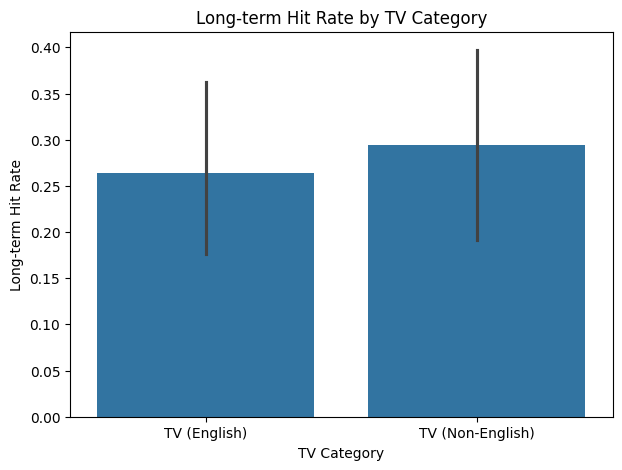

In [52]:
# TV 카테고리별 장기 흥행 비율 시각화
plt.figure(figsize=(7, 5))

sns.barplot(
    data=tv_complete,
    x='category',
    y='long_hit'
)

plt.title('Long-term Hit Rate by TV Category')
plt.xlabel('TV Category')
plt.ylabel('Long-term Hit Rate')

plt.show()

In [53]:
#질문
#English / Non-English 여부에 따라 TV 콘텐츠의 장기흥행 비율이 다른가?

#결과
#English TV의 장기흥행률은 약 26.4%, Non-English TV는 약 29.4%로 나타났다.

#해석
#Non-English 콘텐츠의 비율이 소폭 높았으나 차이는 약 3%p로 크지 않았다. 따라서 현재 데이터에서는 언어 구분 자체가 장기흥행을 강하게 설명하는 특성이라고 판단하기 어렵다.

#로스트아크 전략 연결
#로스트아크 IP 영상화 시 영어권 콘텐츠로 제작하느냐 비영어권 콘텐츠로 제작하느냐 자체보다, 다른 흥행 특성을 추가적으로 살펴볼 필요가 있다.

In [54]:
#EDA 3. 처음 진입했을 때 순위가 장기흥행과 관계있을까?

In [55]:
# 콘텐츠별 Top10 최초 진입 시점의 순위와 시청시간 추출
first_performance = (
    global_df
    .sort_values('week')
    .groupby('content_key', as_index=False)
    .first()[
        ['content_key', 'weekly_rank', 'weekly_hours_viewed']
    ]
    .rename(
        columns={
            'weekly_rank': 'first_rank',
            'weekly_hours_viewed': 'first_week_hours'
        }
    )
)

display(first_performance.head())

,content_key,first_rank,first_week_hours
0,1000 Miles from Christmas,3,6940000
1,14 Peaks: Nothing Is Impossible,7,12170000
2,21 Jump Street,6,11690000
3,211,6,7900000
4,6 Underground,9,7770000


In [56]:
# 완전 관측 TV 콘텐츠에 최초 진입 성과 변수 결합
tv_analysis = tv_complete.merge(
    first_performance,
    on='content_key',
    how='left'
)

display(
    tv_analysis[
        ['content_key', 'category', 'max_cumulative',
         'long_hit', 'first_rank', 'first_week_hours']
    ].head()
)

,content_key,category,max_cumulative,long_hit,first_rank,first_week_hours
0,A Tale Dark & Grimm: Season 1,TV (English),1,0,7,18730000
1,AlRawabi School for Girls: Limited Series,TV (Non-English),3,0,6,11620000
2,Alice in Borderland: Season 1,TV (Non-English),5,1,8,10890000
3,All American: Season 3,TV (English),5,1,2,43970000
4,Another Life: Season 2,TV (English),1,0,9,15760000


In [57]:
# 장기흥행 여부에 따른 최초 진입 순위의 기술통계 비교
display(
    tv_analysis
    .groupby('long_hit')['first_rank']
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
long_hit,,,,,,,,
0,115.0,6.730435,2.403659,1.0,5.0,7.0,9.00,10.0
1,44.0,4.181818,2.895648,1.0,2.0,3.5,6.25,10.0


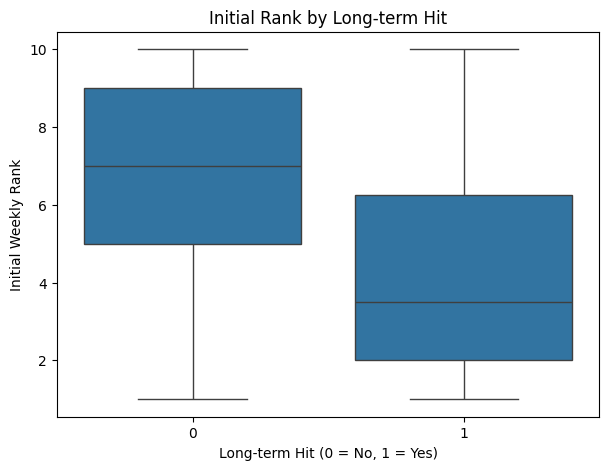

In [58]:
# 장기흥행 여부에 따른 최초 진입 순위 분포 비교
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=tv_analysis,
    x='long_hit',
    y='first_rank'
)

plt.title('Initial Rank by Long-term Hit')
plt.xlabel('Long-term Hit (0 = No, 1 = Yes)')
plt.ylabel('Initial Weekly Rank')

plt.show()

In [59]:
#EDA 3 — 최초 진입 순위와 장기흥행의 관계
#4주 이상 Top 10을 유지한 장기흥행 콘텐츠의 최초 진입 순위는 평균 4.18위, 중앙값 3.5위였으며, 4주 미만 콘텐츠는 평균 6.73위, 중앙값 7위로 나타났다.
#이를 통해 장기흥행 콘텐츠가 Top 10 진입 초기부터 상대적으로 높은 순위를 기록하는 경향을 확인하였다.

In [60]:
#EDA 4: 첫 주 시청시간과 장기흥행의 관계
# 장기흥행 여부에 따른 첫 주 시청시간 기술통계 비교
display(
    tv_analysis
    .groupby('long_hit')['first_week_hours']
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
long_hit,,,,,,,,
0,115.0,1.618626e+07,9.716609e+06,6660000.0,10270000.0,13970000.0,18695000.0,63520000.0
1,44.0,3.552000e+07,2.962563e+07,6950000.0,15735000.0,28210000.0,42205000.0,133120000.0


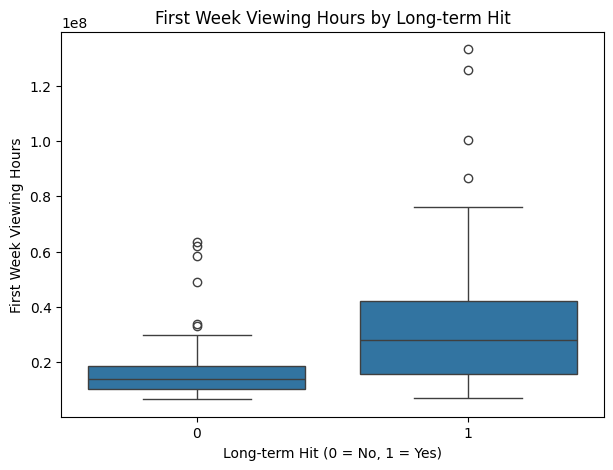

In [61]:
# 장기흥행 여부에 따른 첫 주 시청시간 분포 비교
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=tv_analysis,
    x='long_hit',
    y='first_week_hours'
)

plt.title('First Week Viewing Hours by Long-term Hit')
plt.xlabel('Long-term Hit (0 = No, 1 = Yes)')
plt.ylabel('First Week Viewing Hours')

plt.show()

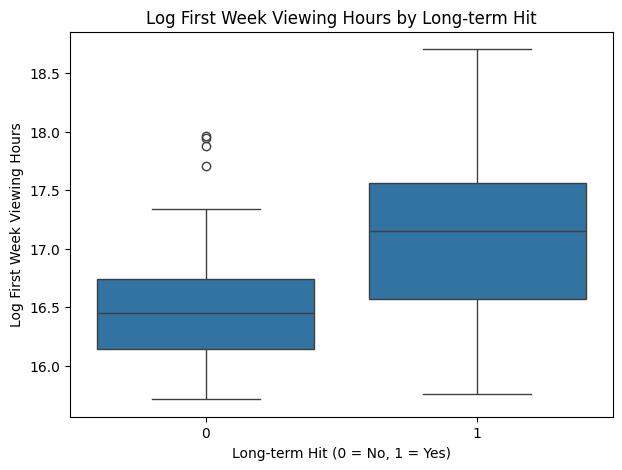

In [62]:
# 첫 주 시청시간을 로그 변환하여 극단적인 값의 영향 완화
tv_analysis['log_first_week_hours'] = np.log1p(
    tv_analysis['first_week_hours']
)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=tv_analysis,
    x='long_hit',
    y='log_first_week_hours'
)

plt.title('Log First Week Viewing Hours by Long-term Hit')
plt.xlabel('Long-term Hit (0 = No, 1 = Yes)')
plt.ylabel('Log First Week Viewing Hours')

plt.show()

In [63]:
#EDA 4 — 첫 주 시청시간과 장기흥행의 관계
#장기흥행 콘텐츠의 첫 주 시청시간은 평균 약 3,552만 시간, 중앙값 약 2,821만 시간으로 나타났다.
#반면 단기흥행 콘텐츠는 평균 약 1,619만 시간, 중앙값 약 1,397만 시간이었다.
#로그 변환 후에도 두 그룹의 분포 차이가 확인되어, 초기 시청 규모가 장기흥행과 관련된 주요 후보 변수임을 확인하였다.

In [64]:
# 최초 진입 순위와 첫 주 시청시간의 상관관계 확인
tv_analysis[
    ['first_rank', 'first_week_hours']
].corr()

,first_rank,first_week_hours
first_rank,1.000000,-0.675663
first_week_hours,-0.675663,1.000000


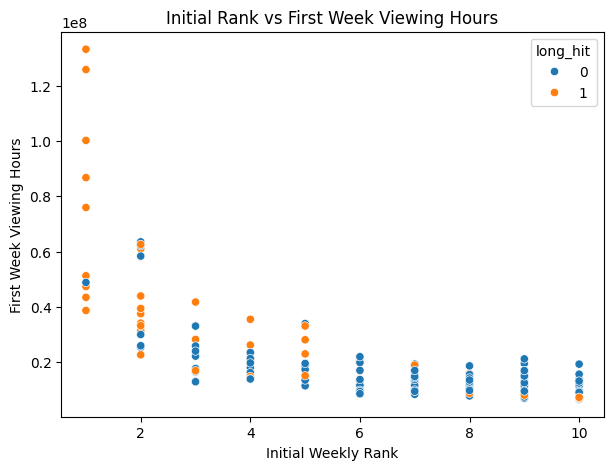

In [65]:
# 최초 진입 순위와 첫 주 시청시간의 관계 시각화
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=tv_analysis,
    x='first_rank',
    y='first_week_hours',
    hue='long_hit'
)

plt.title('Initial Rank vs First Week Viewing Hours')
plt.xlabel('Initial Weekly Rank')
plt.ylabel('First Week Viewing Hours')

plt.show()
#초기 순위가 높고 첫 주 시청시간이 많은 콘텐츠에서 장기흥행 사례가 더 많이 관찰되는 경향이 있다.

In [66]:
#EDA 5. 초기에 여러 국가에서 Top 10에 진입한 콘텐츠가 더 오래 흥행하는가?
# 국가별 데이터에도 콘텐츠 식별용 content_key 생성
country_df['content_key'] = country_df.apply(
    lambda row: row['season_title']
    if pd.notnull(row['season_title'])
    else row['show_title'],
    axis=1
)

In [67]:
# 콘텐츠별 글로벌 최초 관측 주차 추출
first_week_info = (
    global_df
    .groupby('content_key', as_index=False)['week']
    .min()
    .rename(columns={'week': 'first_week'})
)

display(first_week_info.head())

,content_key,first_week
0,1000 Miles from Christmas,2021-12-26
1,14 Peaks: Nothing Is Impossible,2021-12-05
2,21 Jump Street,2021-11-07
3,211,2021-11-14
4,6 Underground,2021-11-21


In [68]:
# 콘텐츠 최초 관측 주차에 Top10에 진입한 국가 수 계산
country_first_week = country_df.merge(
    first_week_info,
    on='content_key',
    how='inner'
)

initial_country_reach = (
    country_first_week[
        country_first_week['week'] == country_first_week['first_week']
    ]
    .groupby('content_key')['country_name']
    .nunique()
    .reset_index(name='initial_country_count')
)

display(initial_country_reach.head())

,content_key,initial_country_count
0,1000 Miles from Christmas,12
1,14 Peaks: Nothing Is Impossible,45
2,21 Jump Street,1
3,211,21
4,6 Underground,12


In [69]:
# 완전 관측 TV 분석 데이터에 초기 국가 확산 수 결합
tv_analysis = tv_analysis.merge(
    initial_country_reach,
    on='content_key',
    how='left'
)

display(
    tv_analysis[
        ['content_key', 'long_hit',
         'first_rank', 'first_week_hours',
         'initial_country_count']
    ].head()
)

,content_key,long_hit,first_rank,first_week_hours,initial_country_count
0,A Tale Dark & Grimm: Season 1,0,7,18730000,19.0
1,AlRawabi School for Girls: Limited Series,0,6,11620000,27.0
2,Alice in Borderland: Season 1,1,8,10890000,13.0
3,All American: Season 3,1,2,43970000,1.0
4,Another Life: Season 2,0,9,15760000,6.0


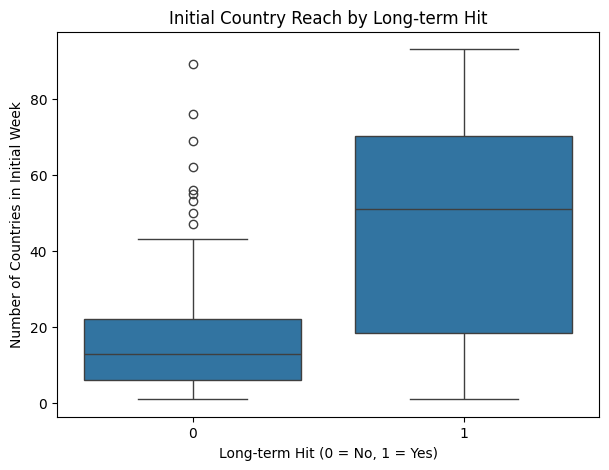

In [70]:
# 장기흥행 여부에 따른 초기 국가 확산 분포 시각화
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=tv_analysis,
    x='long_hit',
    y='initial_country_count'
)

plt.title('Initial Country Reach by Long-term Hit')
plt.xlabel('Long-term Hit (0 = No, 1 = Yes)')
plt.ylabel('Number of Countries in Initial Week')

plt.show()

In [71]:
# 장기흥행 여부에 따른 초기 진입 국가 수 기술통계 비교
display(
    tv_analysis
    .groupby('long_hit')['initial_country_count']
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
long_hit,,,,,,,,
0,111.0,17.666667,16.827647,1.0,6.0,13.0,22.00,89.0
1,44.0,46.977273,28.851253,1.0,18.5,51.0,70.25,93.0


In [72]:
# 초기 국가 확산 변수의 결측치 여부 확인
print(
    tv_analysis['initial_country_count']
    .isnull()
    .sum()
)

4


In [73]:
# 초기 성과 변수와 장기흥행 여부의 상관관계 확인
display(
    tv_analysis[
        [
            'first_rank',
            'first_week_hours',
            'initial_country_count',
            'long_hit'
        ]
    ].corr()
)

,first_rank,first_week_hours,initial_country_count,long_hit
first_rank,1.000000,-0.675663,-0.727838,-0.410633
first_week_hours,-0.675663,1.000000,0.781391,0.443791
initial_country_count,-0.727838,0.781391,1.000000,0.536606
long_hit,-0.410633,0.443791,0.536606,1.000000


In [74]:
# 초기 국가 확산 수가 결측인 콘텐츠 확인
missing_country_count = tv_analysis[
    tv_analysis['initial_country_count'].isnull()
]

display(
    missing_country_count[
        ['content_key', 'category', 'max_cumulative',
         'long_hit', 'first_rank', 'first_week_hours']
    ]
)

,content_key,category,max_cumulative,long_hit,first_rank,first_week_hours
22,Cobra Kai: Season 1,TV (English),2,0,8,13450000
41,Elves: Season 1,TV (Non-English),2,0,10,6660000
66,Locke & Key: Season 1,TV (English),3,0,10,15710000
97,Octonauts: Above & Beyond: Season 1,TV (English),1,0,8,11730000


In [75]:
# 결측 콘텐츠가 국가별 데이터에 존재하는지 확인
missing_keys = missing_country_count['content_key'].tolist()

display(
    country_df[
        country_df['content_key'].isin(missing_keys)
    ][
        ['content_key', 'country_name', 'week',
         'weekly_rank']
    ]
    .sort_values(['content_key', 'week'])
)

,content_key,country_name,week,weekly_rank
1199,Cobra Kai: Season 1,Austria,2022-01-09,10
1776,Cobra Kai: Season 1,Bahamas,2022-01-09,7
2357,Cobra Kai: Season 1,Bahrain,2022-01-09,8
3517,Cobra Kai: Season 1,Belgium,2022-01-09,8
4098,Cobra Kai: Season 1,Bolivia,2022-01-09,9
...,...,...,...,...
41399,Locke & Key: Season 1,Réunion,2021-11-07,10
50678,Locke & Key: Season 1,Ukraine,2021-11-07,9
18179,Locke & Key: Season 1,Hungary,2021-11-14,10
19339,Locke & Key: Season 1,India,2021-11-14,10


In [76]:
# 결측 콘텐츠의 글로벌 최초 등장일과 국가별 최초 등장일 비교
missing_week_check = (
    country_df[
        country_df['content_key'].isin(missing_keys)
    ]
    .groupby('content_key', as_index=False)['week']
    .min()
    .rename(columns={'week': 'country_first_week'})
)

missing_week_check = (
    missing_country_count[
        ['content_key']
    ]
    .merge(
        first_week_info,
        on='content_key',
        how='left'
    )
    .merge(
        missing_week_check,
        on='content_key',
        how='left'
    )
)

missing_week_check['week_difference'] = (
    missing_week_check['country_first_week']
    - missing_week_check['first_week']
).dt.days

display(missing_week_check)

,content_key,first_week,country_first_week,week_difference
0,Cobra Kai: Season 1,2022-01-02,2022-01-09,7.0
1,Elves: Season 1,2021-11-28,2021-12-05,7.0
2,Locke & Key: Season 1,2021-10-24,2021-10-31,7.0
3,Octonauts: Above & Beyond: Season 1,2021-09-12,NaT,NaN


In [77]:
# 국가별 데이터에서 Octonauts 관련 제목이 다른 형태로 존재하는지 확인
display(
    country_df[
        country_df['show_title'].str.contains(
            'Octonauts',
            case=False,
            na=False
        )
    ][
        ['show_title', 'season_title', 'content_key',
         'country_name', 'week']
    ]
    .drop_duplicates()
    .head(30)
)

,show_title,season_title,content_key,country_name,week


In [78]:
# 국가 데이터에서 콘텐츠별 최초 관측 주차 계산
country_content_first_week = (
    country_df
    .groupby('content_key', as_index=False)['week']
    .min()
    .rename(columns={'week': 'country_first_week'})
)

In [79]:
# 국가별 최초 관측 주차에 동시에 Top10에 진입한 국가 수 계산
country_initial = country_df.merge(
    country_content_first_week,
    on='content_key',
    how='left'
)

initial_country_reach_v2 = (
    country_initial[
        country_initial['week'] == country_initial['country_first_week']
    ]
    .groupby('content_key')['country_name']
    .nunique()
    .reset_index(name='initial_country_reach')
)

In [80]:
# TV 분석 데이터에 수정된 초기 국가 확산 변수 결합
tv_analysis_v2 = (
    tv_analysis
    .drop(columns=['initial_country_count'])
    .merge(
        initial_country_reach_v2,
        on='content_key',
        how='left'
    )
)

print(
    '초기 국가 확산 변수 결측치:',
    tv_analysis_v2['initial_country_reach'].isnull().sum()
)

초기 국가 확산 변수 결측치: 1


In [81]:
# 장기흥행 여부에 따른 초기 국가 확산 수 비교
display(
    tv_analysis_v2
    .groupby('long_hit')['initial_country_reach']
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
long_hit,,,,,,,,
0,114.0,14.684211,16.489372,1.0,2.25,10.0,19.75,89.0
1,44.0,39.204545,32.592323,1.0,5.75,41.0,67.75,93.0


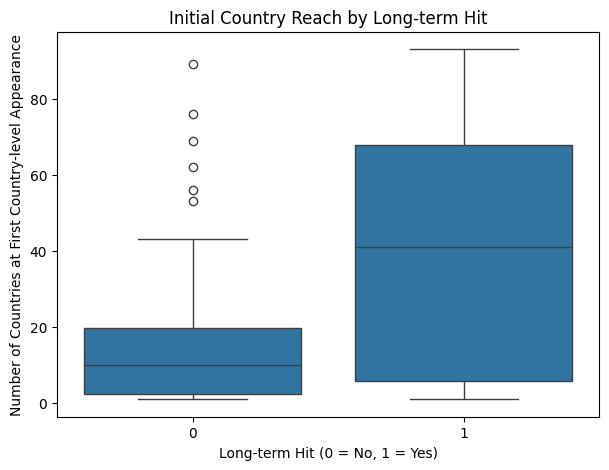

In [82]:
# 장기흥행 여부에 따른 초기 국가 확산 분포 시각화
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=tv_analysis_v2,
    x='long_hit',
    y='initial_country_reach'
)

plt.title('Initial Country Reach by Long-term Hit')
plt.xlabel('Long-term Hit (0 = No, 1 = Yes)')
plt.ylabel('Number of Countries at First Country-level Appearance')

plt.show()

In [83]:
# 초기 성과 변수와 장기흥행 여부의 상관관계 재확인
display(
    tv_analysis_v2[
        [
            'first_rank',
            'first_week_hours',
            'initial_country_reach',
            'long_hit'
        ]
    ].corr()
)

,first_rank,first_week_hours,initial_country_reach,long_hit
first_rank,1.000000,-0.675663,-0.668297,-0.410633
first_week_hours,-0.675663,1.000000,0.780845,0.443791
initial_country_reach,-0.668297,0.780845,1.000000,0.447094
long_hit,-0.410633,0.443791,0.447094,1.000000


In [84]:
#EDA 5 — 초기 글로벌 확산과 장기흥행의 관계
#장기흥행 콘텐츠의 초기 국가 확산 수는 평균 약 39.2개국, 중앙값 41개국으로 나타났으며, 단기흥행 콘텐츠는 평균 약 14.7개국, 중앙값 10개국으로 나타났다.
#이를 통해 장기흥행 콘텐츠가 국가별 Top 10에 처음 등장하는 시점부터 상대적으로 넓은 글로벌 확산 범위를 보이는 경향을 확인하였다.

In [85]:
#로스트아크 시나리오:
#단순히 특정 국가에서 높은 순위를 기록하는 것보다, 공개 초기에 여러 국가에서 동시에 반응을 확보하는 것이 장기흥행과 관련될 가능성이 있다.

In [87]:
## 1차 기본 EDA 요약

### 데이터
#- 분석 기간: 2021-07-04 ~ 2022-01-16
#- Global Top 10: 1,160행
#- Country Top 10: 54,520행
#- 콘텐츠/시즌 단위 분석을 위해 `content_key` 생성

### 장기흥행 기준
#- 완전 관측된 TV 콘텐츠를 기준으로 분석
#- Top 10 유지기간 중앙값: 2주
#- 75% 지점: 4주
#- 본 분석에서는 4주 이상 Top 10 유지 콘텐츠를 장기흥행으로 정의

### 주요 EDA 결과
#1. TV (Non-English)의 장기흥행률이 TV (English)보다 소폭 높았으나 차이는 크지 않았다.
#2. 장기흥행 콘텐츠는 최초 Top 10 진입 순위가 상대적으로 높았다.
#3. 장기흥행 콘텐츠는 첫 주 시청시간이 더 높게 나타났다.
#4. 장기흥행 콘텐츠는 국가별 Top 10 최초 등장 시 더 넓은 국가 확산 범위를 보였다.
#5. 첫 주 시청시간과 초기 국가 확산 범위 사이에는 높은 상관관계가 관찰되었다.

### 현재 데이터의 한계
#Netflix Top 10 데이터만으로는 다음 특성을 확인하기 어렵다.
#- 장르
#- 애니메이션 여부
#- 판타지 여부
#- 에피소드 수
#- 러닝타임
#- 제작 국가
#- 평점 및 인기도
#- 원작/IP 정보

#따라서 다음 단계에서는 TMDB / IMDb 등의 외부 데이터를 결합하여
#장기흥행과 콘텐츠 자체의 특성 간 관계를 추가 분석할 예정이다.